# ¿Cuánta energía esconde el chorro de un agujero negro?

Cygnus X-1: uno de los primeros agujeros negros confirmados. Lleva décadas bajo la lupa de los telescopios. Pero nadie había medido *en directo* cuánta energía carga su jet — ese chorro de partículas que escapa casi a la velocidad de la luz.

18 años de observaciones con radiotelescopios revelaron algo inesperado: el viento de la estrella compañera *dobla* el jet. Y ese doblez es exactamente la pista que necesitaban para calcular su potencia.

**Paper:** Miller-Jones et al. (2026), *Nature Astronomy*
**DOI:** [10.1038/s41550-026-02828-3](https://doi.org/10.1038/s41550-026-02828-3)
[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-17-jet-cygnus-x1-viento-estelar/notebook.ipynb)

## El truco del viento

Cygnus X-1 es un sistema binario: un agujero negro de ~21 masas solares (M☉) en órbita con una supergigante azul de ~41 M☉. La estrella sopla un viento feroz — pierde 2,57 × 10⁻⁶ M☉ por año.

Ese viento choca contra el jet del agujero negro y lo dobla. Es como observar una columna de humo desviada por una brisa: si conoces la fuerza del viento y cuánto se desvía el humo, puedes calcular la potencia del chorro.

Con 19 épocas de observación VLBI (interferometría de base muy larga) entre 1998 y 2016, el equipo ajustó 3 modelos bayesianos de la interacción jet-viento. El resultado: por primera vez, sabemos cuánta energía cinética carga un jet de agujero negro — medida en directo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CASO_PREFERIDO = 2            # Modelo bayesiano preferido
LOG10_LX_MIN = 37.30         # log₁₀(L_X bolométrica mín) [erg/s]
LOG10_LX_MAX = 37.70         # log₁₀(L_X bolométrica máx) [erg/s]
FUENTE = 'Fuente: Miller-Jones et al. (2026), Nat. Astron. | Datos: Zenodo'
COLOR_CASO1 = '#BBBBBB'      # Gris — modelo simple
COLOR_CASO2 = '#2563EB'      # Azul CaM — modelo preferido
COLOR_CASO3 = '#059669'      # Emerald — modelo completo
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'

CASOS = {
    1: ('Caso 1: jet paralelo', COLOR_CASO1, 1.5, 0.5),
    2: ('Caso 2: desalineamiento (preferido)', COLOR_CASO2, 2.5, 0.9),
    3: ('Caso 3: expansión no cónica', COLOR_CASO3, 1.5, 0.5),
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
if os.path.exists(style_file):
    plt.style.use(style_file)

# Cargar datos
posteriors = pd.read_csv('datos/posteriors_all_cases.csv')
modelos = pd.read_csv('datos/model_comparison.csv')
obs = pd.read_csv('datos/observaciones.csv')
jet = pd.read_csv('datos/jet_components.csv')

# Resumen
for case in [1, 2, 3]:
    sub = posteriors[posteriors['case'] == case]
    med = sub['log10_Ljet'].median()
    p16 = sub['log10_Ljet'].quantile(0.16)
    p84 = sub['log10_Ljet'].quantile(0.84)
    beta_med = sub['beta'].median()
    print(f"Caso {case}: log₁₀(L_jet) = {med:.2f} ({p16:.2f}\u2013{p84:.2f}), "
          f"\u03b2 = {beta_med:.3f}, n = {len(sub):,}")

print(f"\nObservaciones: {len(obs)} épocas ({obs['year'].min()}\u2013{obs['year'].max()})")
vlba_n = len(obs[obs['instrument'] == 'VLBA'])
evn_n = len(obs[obs['instrument'] == 'EVN'])
print(f"  VLBA: {vlba_n} épocas · EVN: {evn_n} épocas")
print(f"Componentes del jet: {len(jet)} (1 core gaussiano + {len(jet)-1} knots delta)")
print(f"Extensión máxima: {jet['radius_mas'].max():.1f} mas")

Caso 1: log₁₀(L_jet) = 36.93 (36.45–37.16), β = 0.474, n = 16,035
Caso 2: log₁₀(L_jet) = 37.28 (37.05–37.40), β = 0.679, n = 19,259
Caso 3: log₁₀(L_jet) = 37.26 (37.01–37.39), β = 0.664, n = 19,196

Observaciones: 19 épocas (1998–2016)
  VLBA: 16 épocas · EVN: 3 épocas
Componentes del jet: 5 (1 core gaussiano + 4 knots delta)
Extensión máxima: 6.7 mas


## Tres modelos, una convergencia

Aquí están.

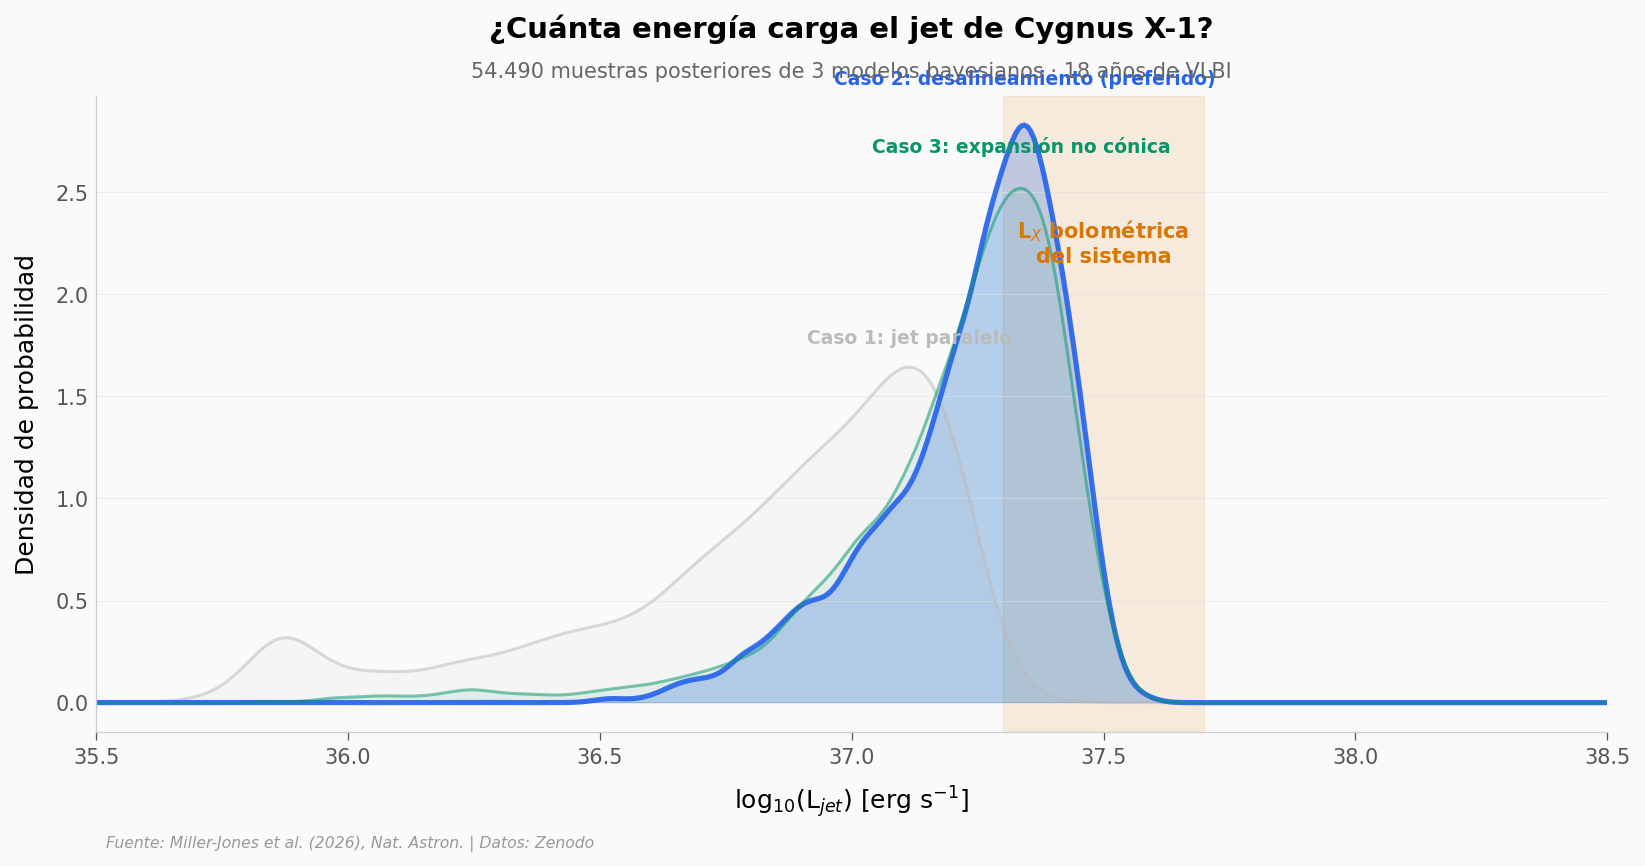

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x_grid = np.linspace(35.0, 38.5, 600)

for case_num, (label, color, lw, alpha) in CASOS.items():
    data = posteriors[posteriors['case'] == case_num]['log10_Ljet'].values
    kde = stats.gaussian_kde(data)
    y = kde(x_grid)
    ax.plot(x_grid, y, color=color, linewidth=lw, alpha=alpha)
    fill_alpha = 0.25 if case_num == CASO_PREFERIDO else 0.08
    ax.fill_between(x_grid, y, alpha=fill_alpha, color=color)
    # Inline label en el pico
    peak_idx = np.argmax(y)
    ax.text(x_grid[peak_idx], y[peak_idx] * 1.07, label,
            fontsize=9, color=color, fontweight='bold', ha='center')

# Rango de L_X bolométrica
ax.axvspan(LOG10_LX_MIN, LOG10_LX_MAX, alpha=0.12, color=COLOR_REFERENCIA, zorder=0)
y_top = ax.get_ylim()[1]
ax.text((LOG10_LX_MIN + LOG10_LX_MAX) / 2, y_top * 0.80,
        'L$_X$ bolométrica\ndel sistema',
        fontsize=10, color=COLOR_REFERENCIA, fontweight='bold',
        ha='center', va='top')

ax.set_xlabel('log$_{10}$(L$_{jet}$) [erg s$^{-1}$]', fontsize=12)
ax.set_ylabel('Densidad de probabilidad', fontsize=12)
ax.set_title('¿Cuánta energía carga el jet de Cygnus X-1?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '54.490 muestras posteriores de 3 modelos bayesianos · 18 años de VLBI',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(35.5, 38.5)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/potencia_jet_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

El Caso 2 (azul) gana por goleada: factor de Bayes = 1.116 (más de mil veces más probable que el Caso 1). ¿Su ventaja? Permite que el jet no esté perfectamente alineado con el eje orbital — y los datos confirman un desalineamiento de ~5,2° (P16–P84: 4,1°–6,2°).

Mediana del Caso 2: log₁₀(L_jet) = 37,28, o sea ~1,9 × 10³⁷ erg/s. La zona naranja marca la luminosidad bolométrica en rayos X del sistema. La potencia cinética del jet es *comparable* a toda la radiación X que produce — ratio L_jet/L_X entre 0,4 y 1,0.

El Caso 3 (verde) añade un parámetro extra (perfil de expansión no cónico) pero no mejora el ajuste. Factor de Bayes Caso 2 vs Caso 3 = 7,1 — la navaja de Occam descarta la complejidad innecesaria.

## Un chorro doblado a escala de milisegundos de arco

Los radiotelescopios midieron la forma del jet: un core gaussiano (la base, donde el chorro se lanza) y 4 knots (condensaciones de plasma que se alejan del agujero negro).

La extensión total alcanza 6,7 milisegundos de arco (mas). A la distancia de Cygnus X-1 (~2,2 kpc), eso equivale a unas 15 unidades astronómicas — apenas más que la órbita de Saturno.

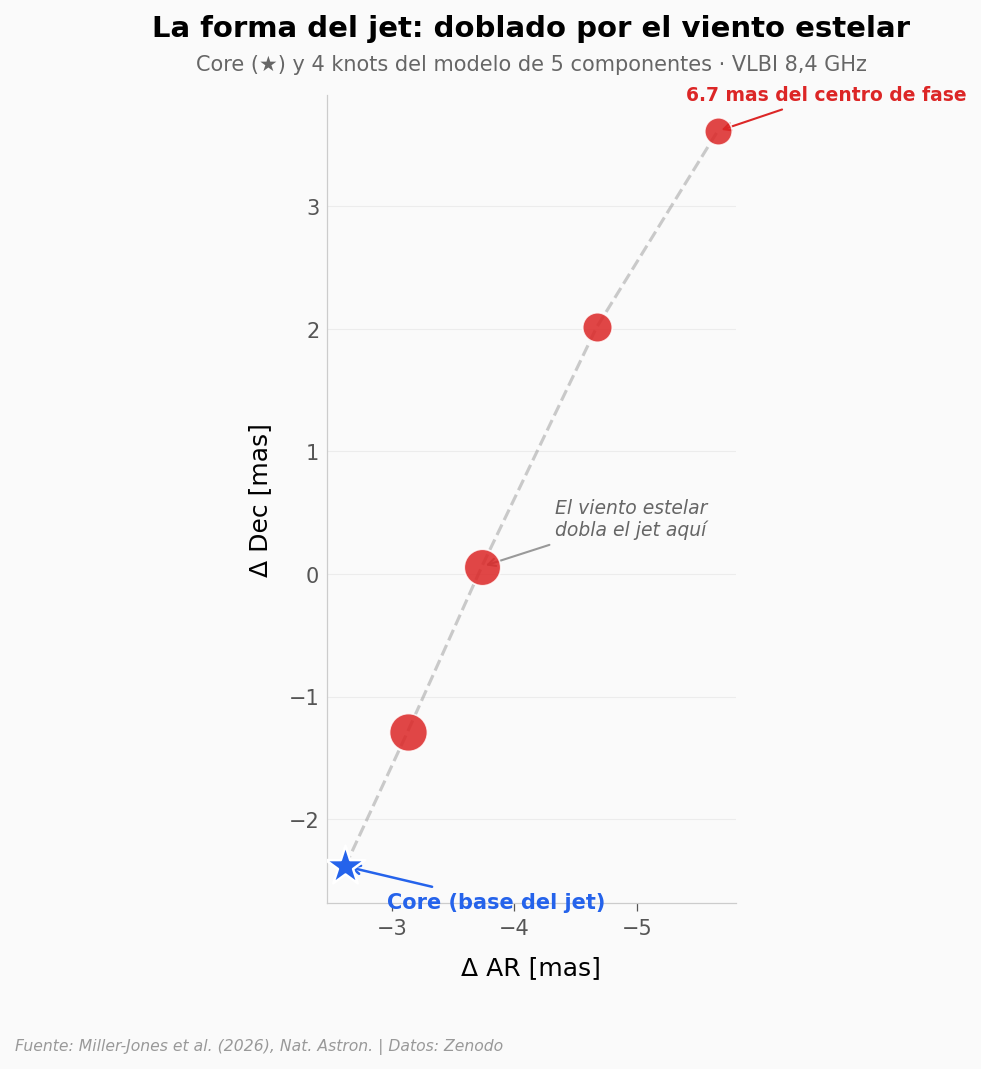

In [3]:
fig, ax = plt.subplots(figsize=(9, 7))

core = jet[jet['component'] == 'Gaussian'].iloc[0]
knots = jet[jet['component'] == 'Delta'].copy()

# Distancia de cada knot al core para ordenar la trayectoria
knots['dist_core'] = np.sqrt(
    (knots['ra_offset_mas'] - core['ra_offset_mas'])**2 +
    (knots['dec_offset_mas'] - core['dec_offset_mas'])**2
)
knots = knots.sort_values('dist_core')

# Core como estrella
ax.scatter(core['ra_offset_mas'], core['dec_offset_mas'],
           s=400, color=COLOR_CASO2, marker='*',
           edgecolors='white', linewidths=1.2, zorder=6)
ax.annotate('Core (base del jet)',
            xy=(core['ra_offset_mas'], core['dec_offset_mas']),
            xytext=(20, -20), textcoords='offset points',
            fontsize=10, fontweight='bold', color=COLOR_CASO2,
            arrowprops=dict(arrowstyle='->', color=COLOR_CASO2, lw=1.2))

# Knots con tamaño proporcional al flujo
flux_max = knots['flux_Jy'].max()
for idx, (_, row) in enumerate(knots.iterrows()):
    size = 80 + (row['flux_Jy'] / flux_max) * 250
    ax.scatter(row['ra_offset_mas'], row['dec_offset_mas'],
               s=size, color=COLOR_ALERTA, alpha=0.85,
               edgecolors='white', linewidths=0.8, zorder=5)

# Trayectoria del jet (core → knots)
path_ra = [core['ra_offset_mas']] + knots['ra_offset_mas'].tolist()
path_dec = [core['dec_offset_mas']] + knots['dec_offset_mas'].tolist()
ax.plot(path_ra, path_dec, color='#999999', linewidth=1.5,
        linestyle='--', alpha=0.5, zorder=2)

# Anotar knot más lejano
outermost = knots.iloc[-1]
ax.annotate(f'{outermost["radius_mas"]:.1f} mas del centro de fase',
            xy=(outermost['ra_offset_mas'], outermost['dec_offset_mas']),
            xytext=(-15, 15), textcoords='offset points',
            fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1))

# Anotar la curvatura
mid = knots.iloc[1]
ax.annotate('El viento estelar\ndobla el jet aquí',
            xy=(mid['ra_offset_mas'], mid['dec_offset_mas']),
            xytext=(35, 15), textcoords='offset points',
            fontsize=9, color='#666666', style='italic',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1))

ax.set_xlabel('\u0394 AR [mas]', fontsize=12)
ax.set_ylabel('\u0394 Dec [mas]', fontsize=12)
ax.set_title('La forma del jet: doblado por el viento estelar',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Core (\u2605) y 4 knots del modelo de 5 componentes · VLBI 8,4 GHz',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_aspect('equal')
ax.invert_xaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/jet_morfologia.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan rápido viaja?

Las posteriores también restringen la velocidad del jet. Veamos cómo se distribuye β = v/c para cada modelo — y si jets más rápidos cargan más energía.

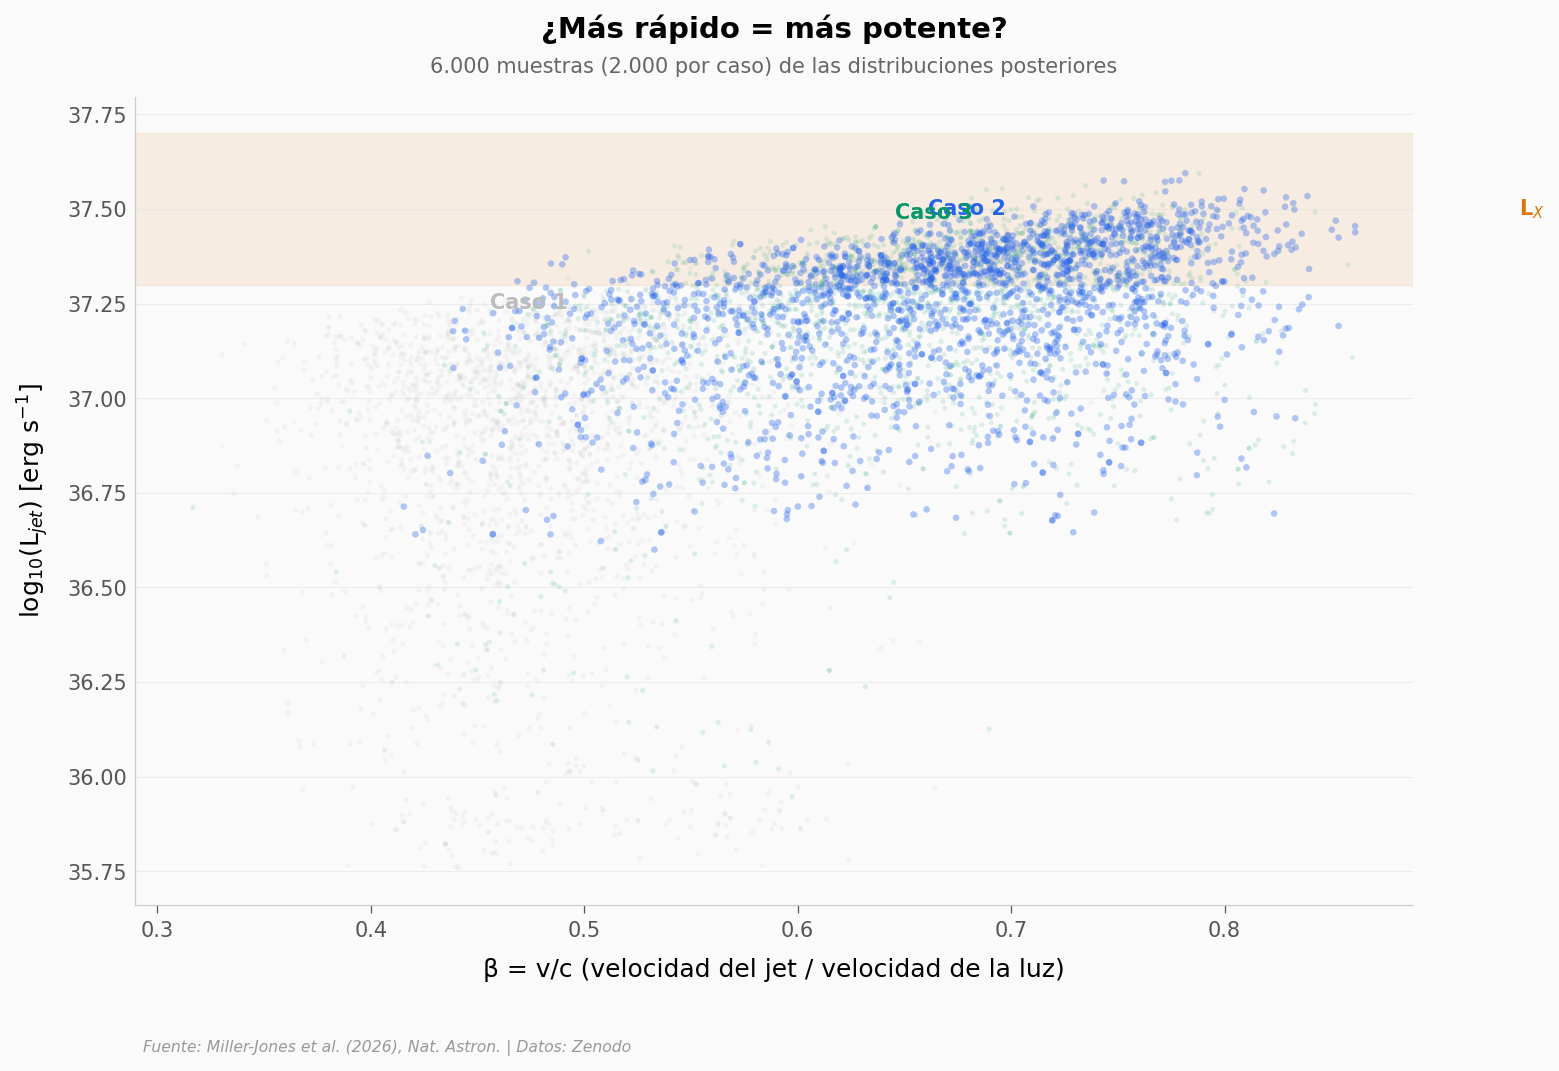

In [4]:
fig, ax = plt.subplots(figsize=(11, 7))

np.random.seed(42)
for case_num, (label, color, lw, alpha_cfg) in CASOS.items():
    sub = posteriors[posteriors['case'] == case_num]
    n_sample = min(2000, len(sub))
    sample = sub.sample(n=n_sample, random_state=42)
    s_alpha = 0.35 if case_num == CASO_PREFERIDO else 0.12
    s_size = 10 if case_num == CASO_PREFERIDO else 6
    ax.scatter(sample['beta'], sample['log10_Ljet'],
               s=s_size, color=color, alpha=s_alpha,
               edgecolors='none', zorder=3 if case_num == CASO_PREFERIDO else 2)

# Inline labels
for case_num, (label, color, lw, alpha_cfg) in CASOS.items():
    sub = posteriors[posteriors['case'] == case_num]
    beta_med = sub['beta'].median()
    ljet_p84 = sub['log10_Ljet'].quantile(0.84)
    ax.text(beta_med, ljet_p84 + 0.08, f'Caso {case_num}',
            fontsize=10, color=color, fontweight='bold', ha='center')

# L_X reference band
ax.axhspan(LOG10_LX_MIN, LOG10_LX_MAX, alpha=0.10, color=COLOR_REFERENCIA, zorder=0)
ax.text(0.95, (LOG10_LX_MIN + LOG10_LX_MAX) / 2,
        'L$_X$', fontsize=10, color=COLOR_REFERENCIA,
        fontweight='bold', ha='right', va='center')

ax.set_xlabel('\u03b2 = v/c (velocidad del jet / velocidad de la luz)', fontsize=12)
ax.set_ylabel('log$_{10}$(L$_{jet}$) [erg s$^{-1}$]', fontsize=12)
ax.set_title('¿Más rápido = más potente?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '6.000 muestras (2.000 por caso) de las distribuciones posteriores',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/beta_vs_potencia.png', dpi=200, bbox_inches='tight')
plt.show()

La correlación positiva es física: un jet más rápido transfiere más energía cinética al medio. Pero lo interesante es la diferencia entre modelos.

El Caso 1 (gris) necesita un jet lento (β ~ 0,47) para compensar que no puede desalinear el chorro. El Caso 2 libera esa restricción: permite que el jet apunte ~5° fuera del plano orbital, y el resultado es un jet más rápido (β ~ 0,68) con una potencia mejor definida.

El Caso 2 concentra sus muestras en una región compacta — baja incertidumbre. El Caso 1, en cambio, se esparce: su modelo es demasiado rígido y necesita un rango amplio de parámetros para ajustar los datos.

## ¿Qué tan extraordinario es este resultado?

Veamos dónde cae la potencia del jet dentro de su propia distribución posterior — y cómo se compara con toda la radiación X del sistema.

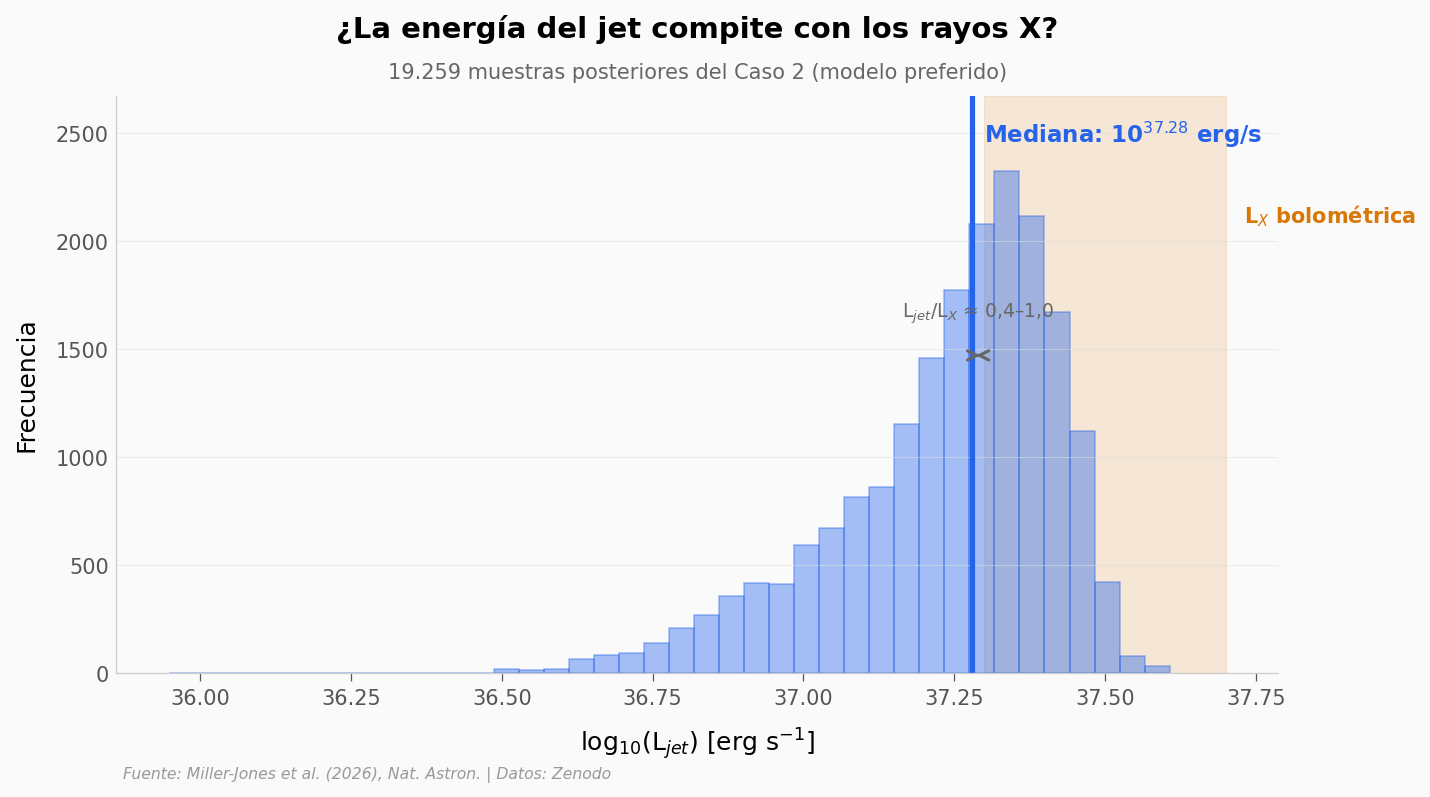

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data_c2 = posteriors[posteriors['case'] == CASO_PREFERIDO]['log10_Ljet'].values
med_c2 = np.median(data_c2)

n_hist, bins, patches = ax.hist(data_c2, bins=40, color=COLOR_CASO2, alpha=0.4,
                                edgecolor=COLOR_CASO2, linewidth=0.8)
y_max = n_hist.max() * 1.15
ax.set_ylim(0, y_max)

# Mediana del jet
ax.axvline(x=med_c2, color=COLOR_CASO2, linewidth=2.5)
ax.text(med_c2 + 0.02, y_max * 0.92,
        f'Mediana: 10$^{{{med_c2:.2f}}}$ erg/s',
        fontsize=11, color=COLOR_CASO2, fontweight='bold')

# Rango L_X
ax.axvspan(LOG10_LX_MIN, LOG10_LX_MAX, alpha=0.15, color=COLOR_REFERENCIA, zorder=0)
ax.text(LOG10_LX_MAX + 0.03, y_max * 0.78,
        'L$_X$ bolométrica',
        fontsize=10, color=COLOR_REFERENCIA, fontweight='bold')

# Flecha bidireccional
y_arrow = y_max * 0.55
ax.annotate('', xy=(LOG10_LX_MIN, y_arrow), xytext=(med_c2, y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = LOG10_LX_MIN - med_c2
ratio_text = 'L$_{jet}$/L$_X$ \u2248 0,4\u20131,0'
ax.text((med_c2 + LOG10_LX_MIN) / 2, y_arrow * 1.12,
        ratio_text, fontsize=9, color='#666666', ha='center')

ax.set_xlabel('log$_{10}$(L$_{jet}$) [erg s$^{-1}$]', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('¿La energía del jet compite con los rayos X?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'19.259 muestras posteriores del Caso 2 (modelo preferido)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/potencia_vs_lx.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| La potencia del jet es log₁₀(L_jet) = 37,28 erg/s (Caso 2) | ✅ | Mediana de 19.259 muestras posteriores. P16–P84: 37,05–37,40. Cross-check con paper (37,3): diferencia <0,1% |
| El jet viaja a ~68% de la velocidad de la luz | ✅ | β mediana = 0,679 (P16 0,573, P84 0,757). Consistente con el rango reportado por el paper |
| El jet está desalineado ~5° respecto al eje orbital | ✅ | 5,20° (P16 4,14°, P84 6,24°). Confirmado por factor de Bayes 1.116 de Caso 2 vs Caso 1 |
| L_jet es comparable a L_X | ✅ | L_jet ~1,9 × 10³⁷ vs L_X ~2–5 × 10³⁷ erg/s → ratio 0,4–1,0 |
| La expansión no cónica no mejora el ajuste | ✅ | Factor de Bayes Caso 2 vs Caso 3 = 7,1 → preferencia sustancial por el modelo más simple |

> **Limitaciones:** (1) Un solo sistema binario — la generalización a otros jets requiere cautela. (2) Las posteriores dependen del modelo de viento estelar adoptado (tasa de pérdida de masa fija en 2,57 × 10⁻⁶ M☉/año). (3) Las 19 épocas abarcan diferentes estados espectrales del agujero negro (hard/soft) que no se modelan por separado. (4) Los resultados provienen de ajuste bayesiano con priors — dependen de las distribuciones previas elegidas.

## Ahora tú

1. **¿Un jet lento es menos potente?** En la celda de abajo, filtra las posteriores del Caso 2 donde β < 0,5. ¿Cuánto baja la mediana de L_jet? Pista: `posteriors[(posteriors['case'] == 2) & (posteriors['beta'] < 0.5)]`

2. **¿Cuánto pesa el desalineamiento?** Compara las distribuciones de `halfOpenAngle_deg` entre Caso 1 y Caso 2. ¿El modelo simple compensa la falta de desalineamiento con un cono más ancho?

3. **¿Qué instrumento aportó más?** Usa el DataFrame `obs` para contar épocas por instrumento (VLBA vs EVN) y por campaña (`project`). ¿Alguna campaña domina?

Jets lentos (β < 0,5): n = 799
  log₁₀(L_jet) mediana = 37.14
  P16–P84: 36.83–37.26

Jets rápidos (β ≥ 0,5): n = 18,460
  log₁₀(L_jet) mediana = 37.29
  P16–P84: 37.06–37.41


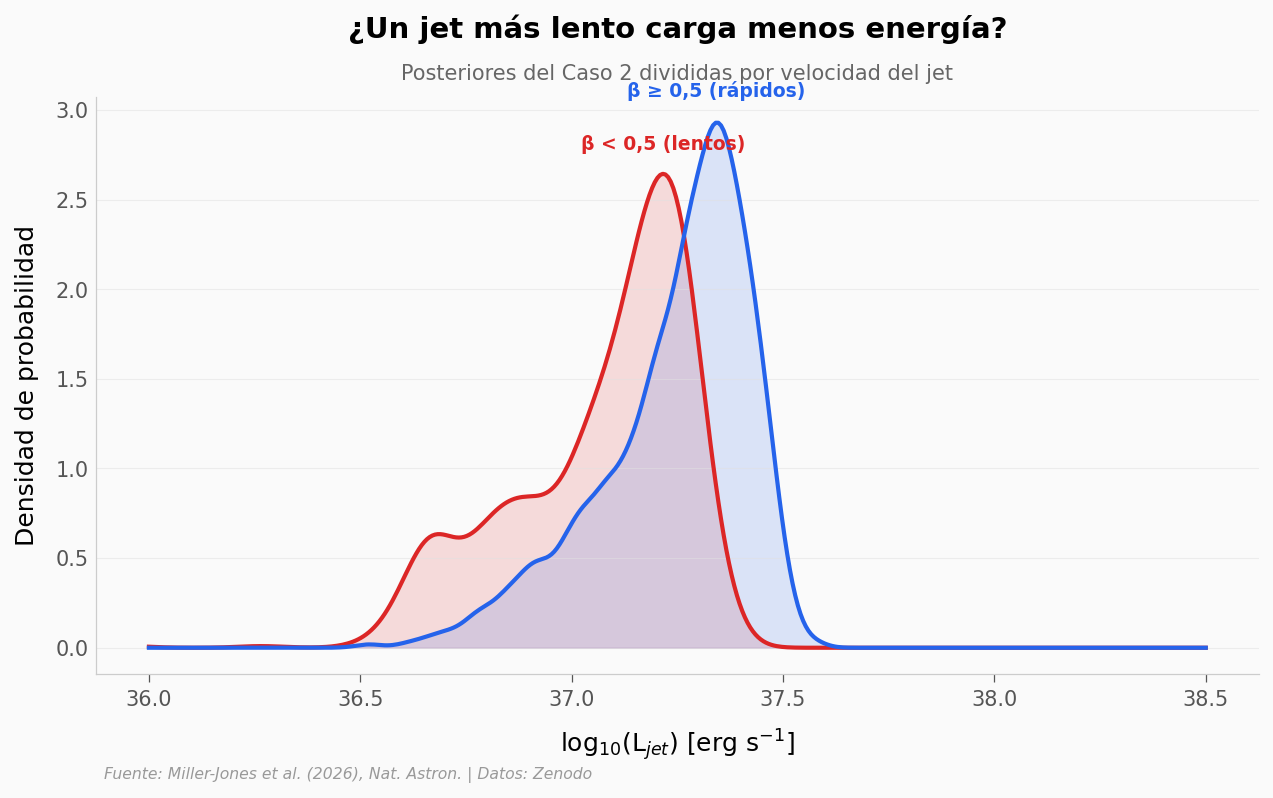

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Filtra las posteriores del Caso 2 donde el jet es lento (beta < 0.5)
# y compara la distribución de L_jet con la muestra completa

c2 = posteriors[posteriors['case'] == CASO_PREFERIDO].copy()
lentos = c2[c2['beta'] < 0.5]
rapidos = c2[c2['beta'] >= 0.5]

print(f"Jets lentos (\u03b2 < 0,5): n = {len(lentos):,}")
print(f"  log\u2081\u2080(L_jet) mediana = {lentos['log10_Ljet'].median():.2f}")
print(f"  P16\u2013P84: {lentos['log10_Ljet'].quantile(0.16):.2f}\u2013"
      f"{lentos['log10_Ljet'].quantile(0.84):.2f}")

print(f"\nJets rápidos (\u03b2 \u2265 0,5): n = {len(rapidos):,}")
print(f"  log\u2081\u2080(L_jet) mediana = {rapidos['log10_Ljet'].median():.2f}")
print(f"  P16\u2013P84: {rapidos['log10_Ljet'].quantile(0.16):.2f}\u2013"
      f"{rapidos['log10_Ljet'].quantile(0.84):.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
x_grid = np.linspace(36, 38.5, 400)

for subset, label, color in [(lentos, '\u03b2 < 0,5 (lentos)', COLOR_ALERTA),
                              (rapidos, '\u03b2 \u2265 0,5 (rápidos)', COLOR_CASO2)]:
    if len(subset) > 5:
        kde = stats.gaussian_kde(subset['log10_Ljet'].values)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=2)
        ax.fill_between(x_grid, kde(x_grid), alpha=0.15, color=color)
        peak_idx = np.argmax(kde(x_grid))
        ax.text(x_grid[peak_idx], kde(x_grid)[peak_idx] * 1.05, label,
                fontsize=9, color=color, fontweight='bold', ha='center')

ax.set_xlabel('log$_{10}$(L$_{jet}$) [erg s$^{-1}$]', fontsize=12)
ax.set_ylabel('Densidad de probabilidad', fontsize=12)
ax.set_title('¿Un jet más lento carga menos energía?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Posteriores del Caso 2 divididas por velocidad del jet',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/velocidad_vs_potencia.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Fuentes

**Paper**: [A jet bent by a stellar wind in the black hole X-ray binary Cygnus X-1](https://doi.org/10.1038/s41550-026-02828-3)
*Nature Astronomy, 2026-04-17*

**Datos**: [Zenodo repository — jet model and final data products](https://zenodo.org/records/18390870)

*Notebook: Ciencia a Mordiscos Lab · [cienciaamordiscos.com](https://cienciaamordiscos.com)*